In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv(r"C:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\apple_feature_engineered.csv")

In [3]:
df.shape

(1132, 22)

In [4]:
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target,...,Negative_Sentiment,Neutral_Sentiment,article_count,Lag1,Lag2,Lag3,Lag5,RSI,MACD,Signal_Line
0,2017-10-05,36.193485,36.205132,35.881373,35.911650,85135200,0.012445,36.335905,36.659574,36.172497,...,0.008,0.925,1.0,35.748585,35.981518,35.825451,35.702003,38.064917,-0.284222,-0.258333
1,2017-11-27,40.694866,40.926288,40.519548,40.919275,82867200,-0.005029,40.163732,37.868176,40.456429,...,0.008,0.926,1.0,40.900558,40.898220,40.472790,39.773842,51.324818,0.770903,0.825436
2,2017-11-30,40.171238,40.239026,39.374124,39.839299,166108800,0.013984,40.322109,38.067460,39.984238,...,0.021,0.804,1.0,39.617229,40.456429,40.694866,40.898220,42.328513,0.570635,0.728934
3,2018-01-31,39.138016,39.374113,38.920623,39.007112,129915600,0.002755,40.695436,40.410276,39.219841,...,0.009,0.937,1.0,39.030506,39.261925,40.091763,40.725227,33.186061,-0.231234,0.065413
4,2018-03-16,41.783184,42.041364,41.689298,41.931049,157618800,-0.003526,41.453182,40.421219,41.144764,...,0.011,0.917,1.0,41.931046,41.881760,42.240883,42.243217,47.417043,0.583631,0.574672


In [5]:
df.columns.tolist()

['Date',
 'Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'Daily_Return',
 'MA20',
 'MA50',
 'Target',
 'Sentiment',
 'Positive_Sentiment',
 'Negative_Sentiment',
 'Neutral_Sentiment',
 'article_count',
 'Lag1',
 'Lag2',
 'Lag3',
 'Lag5',
 'RSI',
 'MACD',
 'Signal_Line']

In [6]:
df = df.dropna()

In [7]:
df.shape

(1132, 22)

In [8]:
features = ['Close',
    'Open',
    'High',
    'Low',
    'Volume',
    'Daily_Return',
    'MA20',
    'MA50',
    'Lag1',
    'Lag2',
    'Lag3',
    'Lag5',
    'RSI',
    'MACD',
    'Signal_Line',
    'Sentiment',
    'Positive_Sentiment',
    'Negative_Sentiment',
    'Neutral_Sentiment',
    'article_count']

# Keep only these columns + target
data = df[features].values

print('Data shape:', data.shape)
print('First 5 rows:')
print(data[:5])

Data shape: (1132, 20)
First 5 rows:
[[ 3.61934853e+01  3.59116501e+01  3.62051320e+01  3.58813729e+01
   8.51352000e+07  1.24452623e-02  3.63359053e+01  3.66595736e+01
   3.57485847e+01  3.59815178e+01  3.58254509e+01  3.57020035e+01
   3.80649172e+01 -2.84221877e-01 -2.58332724e-01  9.97000000e-01
   6.70000000e-02  8.00000000e-03  9.25000000e-01  1.00000000e+00]
 [ 4.06948662e+01  4.09192751e+01  4.09262875e+01  4.05195480e+01
   8.28672000e+07 -5.02908271e-03  4.01637318e+01  3.78681763e+01
   4.09005585e+01  4.08982201e+01  4.04727898e+01  3.97738419e+01
   5.13248176e+01  7.70903290e-01  8.25435753e-01  9.97000000e-01
   6.50000000e-02  8.00000000e-03  9.26000000e-01  1.00000000e+00]
 [ 4.01712379e+01  3.98392991e+01  4.02390261e+01  3.93741238e+01
   1.66108800e+08  1.39840290e-02  4.03221090e+01  3.80674598e+01
   3.96172295e+01  4.04564285e+01  4.06948662e+01  4.08982201e+01
   4.23285130e+01  5.70635092e-01  7.28933836e-01  9.89000000e-01
   1.74000000e-01  2.10000000e-02  8.

In [9]:
# Scale all features between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print('Scaled data shape:', data_scaled.shape)
print('First 5 scaled rows:')
print(data_scaled[:5])

Scaled data shape: (1132, 20)
First 5 scaled rows:
[[0.01222238 0.00873722 0.00810641 0.01100159 0.1790352  0.56045137
  0.         0.         0.         0.         0.         0.
  0.38734031 0.40329072 0.38760633 0.99849473 0.23183391 0.05095541
  0.77511244 0.        ]
 [0.03461916 0.03373942 0.03157742 0.0343074  0.17238808 0.47305044
  0.0198766  0.00634691 0.02589297 0.0247395  0.02336579 0.0204596
  0.53457125 0.47200431 0.46562291 0.99849473 0.22491349 0.05095541
  0.77811094 0.        ]
 [0.03201383 0.02834729 0.02816073 0.02855189 0.4163549  0.56814777
  0.02069899 0.00739344 0.01944317 0.02251653 0.02448234 0.02610922
  0.43468103 0.45896211 0.45867608 0.99448068 0.60207612 0.13375796
  0.41229385 0.        ]
 [0.02687299 0.02419232 0.02386085 0.02627315 0.31027885 0.51198137
  0.02263756 0.01969661 0.0164944  0.01650611 0.02145007 0.02523999
  0.33316806 0.40674147 0.41091162 0.99749122 0.18685121 0.05732484
  0.81109445 0.        ]
 [0.04003412 0.03879103 0.03712096 0.04018

In [20]:
# How many past days to use to predict the next day
sequence_length = 60

# Create sequences
X = []
y = []

for i in range(sequence_length, len(data_scaled)):
    # Take the past 60 days as input
    X.append(data_scaled[i - sequence_length:i])
    # The target is the Close price on the current day (index 0 = Close)
    y.append(data_scaled[i, 0])

X = np.array(X)
y = np.array(y)

print('X shape:', X.shape, '(samples, timesteps, features)')
print('y shape:', y.shape)

X shape: (1072, 60, 20) (samples, timesteps, features)
y shape: (1072,)


In [21]:
# 80% for training, 20% for testing
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)

Train shape: (857, 60, 20)
Test shape:  (215, 60, 20)


In [22]:
# Build the model
model = Sequential([
    # First LSTM layer with 50 units
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    
    # Second LSTM layer with 50 units
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    
    # Output layer - predicts one value (the price)
    Dense(25),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Show the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        14,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,701 (139.46 KB)

 Trainable params: 35,701 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [24]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print('Training complete')

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0190 - val_loss: 0.0027
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0057 - val_loss: 0.0052
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0047 - val_loss: 0.0029
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0042 - val_loss: 0.0066
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0034 - val_loss: 8.3926e-04
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0033 - val_loss: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0033 - val_loss: 0.0019
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0030 - val_loss: 7.4151e-04
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0025 - val_loss: 7.5702e-04
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0026 - val_loss: 0.0014
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

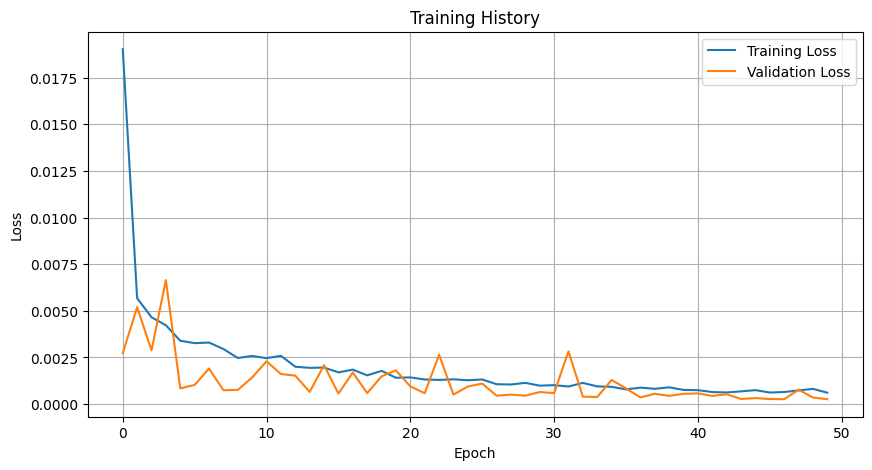

In [25]:
# Plot training loss and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Predict on the test set
predictions_scaled = model.predict(X_test)

print('Predictions shape:', predictions_scaled.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predictions shape: (215, 1)


In [27]:
# Create a dummy array with the same shape as original data
# so I can inverse the scaling for the Close column

dummy_pred = np.zeros((len(predictions_scaled), len(features)))
dummy_pred[:, 0] = predictions_scaled.flatten()
predictions_real = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_actual = np.zeros((len(y_test), len(features)))
dummy_actual[:, 0] = y_test
y_test_real = scaler.inverse_transform(dummy_actual)[:, 0]

print('First 5 predictions vs actual:')
for i in range(5):
    print(f'Predicted: ${predictions_real[i]:.2f}  |  Actual: ${y_test_real[i]:.2f}')

First 5 predictions vs actual:
Predicted: $183.43  |  Actual: $191.72
Predicted: $185.66  |  Actual: $193.00
Predicted: $188.51  |  Actual: $192.32
Predicted: $190.40  |  Actual: $192.00
Predicted: $191.58  |  Actual: $190.27


In [28]:
rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
mae = mean_absolute_error(y_test_real, predictions_real)
r2 = r2_score(y_test_real, predictions_real)

print('LSTM Model Performance:')
print(f'  RMSE: {rmse:.2f}')
print(f'  MAE:  {mae:.2f}')
print(f'  R2:   {r2:.4f}')

LSTM Model Performance:
  RMSE: 5.57
  MAE:  4.38
  R2:   0.9421


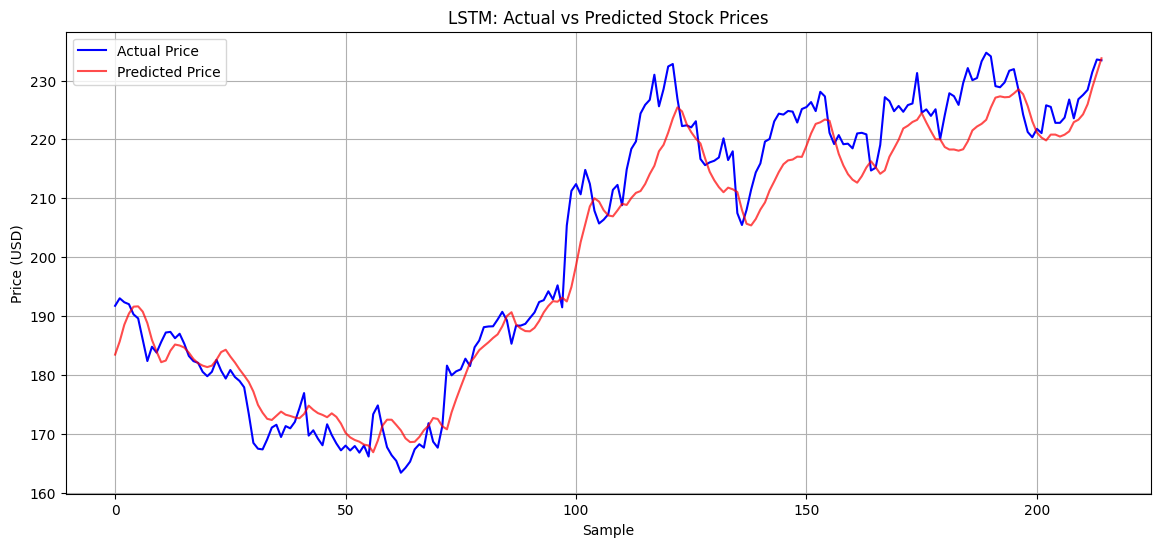

In [29]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label='Actual Price', color='blue')
plt.plot(predictions_real, label='Predicted Price', color='red', alpha=0.7)
plt.title('LSTM: Actual vs Predicted Stock Prices')
plt.xlabel('Sample')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# --- Permutation Feature Importance for LSTM ---

# Your 20 features
feature_names = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'Daily_Return', 'MA20', 'MA50',
    'Lag1', 'Lag2', 'Lag3', 'Lag5',
    'RSI', 'MACD', 'Signal_Line',
    'Sentiment', 'Positive_Sentiment', 'Negative_Sentiment',
    'Neutral_Sentiment', 'article_count'
]

# Get baseline predictions
baseline_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform using dummy array (since one scaler)
baseline_dummy = np.zeros((len(baseline_pred_scaled), len(feature_names)))
baseline_dummy[:, 0] = baseline_pred_scaled.flatten()
baseline_pred_real = scaler.inverse_transform(baseline_dummy)[:, 0]

baseline_rmse = np.sqrt(mean_squared_error(y_test_real, baseline_pred_real))

print(f'Baseline RMSE: {baseline_rmse:.4f}')
print()

# Test each feature
importances = []

for i in range(X_test.shape[2]):
    # Copy the test data
    X_test_shuffled = X_test.copy()
    
    # Shuffle feature i across all sequences
    np.random.seed(42)
    shuffled_col = X_test_shuffled[:, :, i].flatten()
    np.random.shuffle(shuffled_col)
    X_test_shuffled[:, :, i] = shuffled_col.reshape(X_test_shuffled[:, :, i].shape)
    
    # Predict with the shuffled feature
    shuffled_pred_scaled = model.predict(X_test_shuffled, verbose=0)
    
    # Inverse transform
    shuffled_dummy = np.zeros((len(shuffled_pred_scaled), len(feature_names)))
    shuffled_dummy[:, 0] = shuffled_pred_scaled.flatten()
    shuffled_pred_real = scaler.inverse_transform(shuffled_dummy)[:, 0]
    
    # Calculate how much the error increased
    shuffled_rmse = np.sqrt(mean_squared_error(y_test_real, shuffled_pred_real))
    importance = shuffled_rmse - baseline_rmse
    
    importances.append(importance)
    print(f'{feature_names[i]:20s} → RMSE increase: {importance:.4f}')

# Create importance DataFrame
import pandas as pd
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('\n=== Feature Importance (sorted) ===')
print(importance_df.to_string(index=False))

Baseline RMSE: 5.5694

Close                → RMSE increase: 0.8720
Open                 → RMSE increase: 1.8010
High                 → RMSE increase: 0.1654
Low                  → RMSE increase: 2.3706
Volume               → RMSE increase: -0.0214
Daily_Return         → RMSE increase: 0.4471
MA20                 → RMSE increase: 1.4776
MA50                 → RMSE increase: 0.1803
Lag1                 → RMSE increase: 1.7249
Lag2                 → RMSE increase: 2.3086
Lag3                 → RMSE increase: 1.3584
Lag5                 → RMSE increase: 0.0065
RSI                  → RMSE increase: 1.6793
MACD                 → RMSE increase: 1.3901
Signal_Line          → RMSE increase: -0.0982
Sentiment            → RMSE increase: -0.0824
Positive_Sentiment   → RMSE increase: 0.4068
Negative_Sentiment   → RMSE increase: 0.5819
Neutral_Sentiment    → RMSE increase: 0.0206
article_count        → RMSE increase: 0.0258

=== Feature Importance (sorted) ===
           Feature  Importance
      

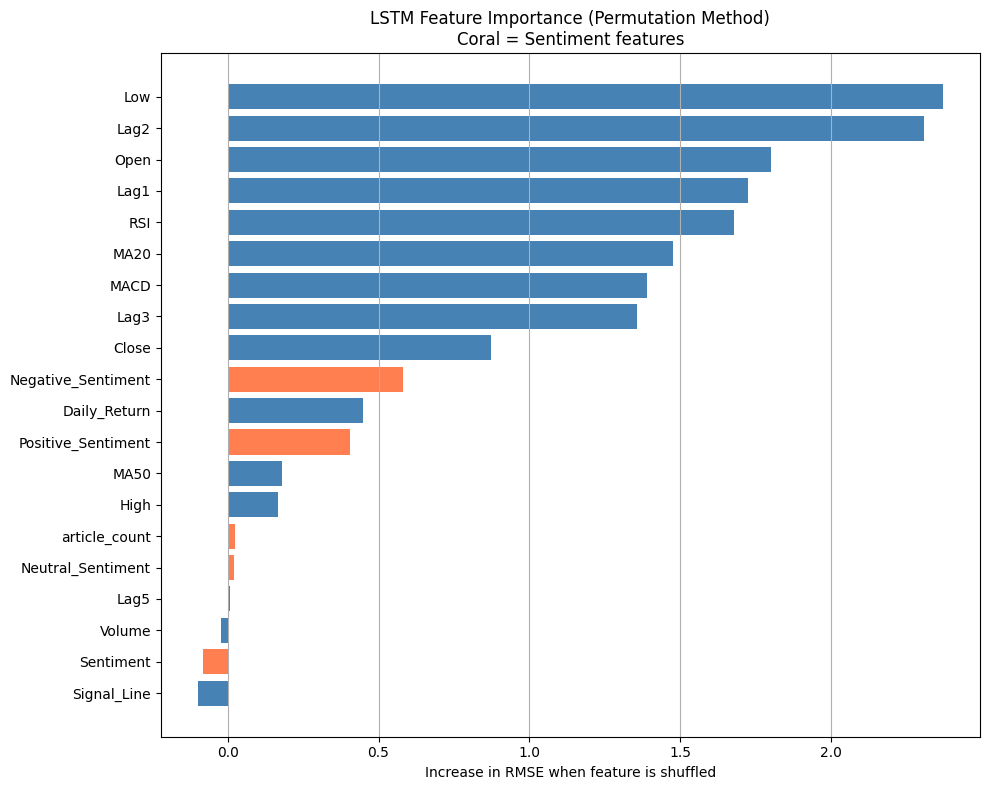


Total sentiment importance: 0.9527


In [33]:
# Plot feature importance
plt.figure(figsize=(10, 8))

# Highlight sentiment features in coral
colors = ['coral' if 'ent' in f.lower() or 'article' in f.lower() 
          else 'steelblue' for f in importance_df['Feature']]

plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
plt.gca().invert_yaxis()
plt.title('LSTM Feature Importance (Permutation Method)\nCoral = Sentiment features')
plt.xlabel('Increase in RMSE when feature is shuffled')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# Print sentiment total contribution
sentiment_features = ['Sentiment', 'Positive_Sentiment', 'Negative_Sentiment',
                      'Neutral_Sentiment', 'article_count']
sentiment_total = importance_df[importance_df['Feature'].isin(sentiment_features)]['Importance'].sum()
print(f"\nTotal sentiment importance: {sentiment_total:.4f}")

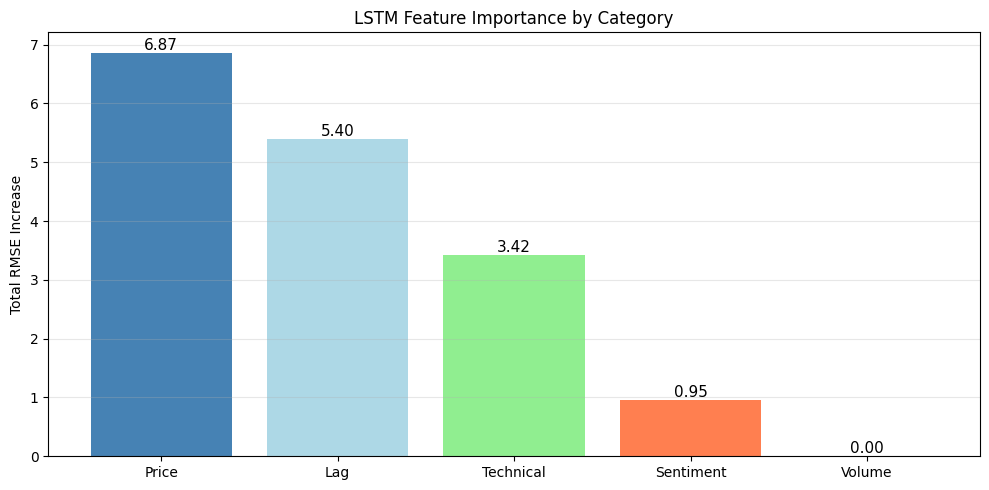

In [34]:
# Group features by category
categories = {
    'Price': ['Close', 'Open', 'High', 'Low', 'MA20', 'MA50'],
    'Lag': ['Lag1', 'Lag2', 'Lag3', 'Lag5'],
    'Technical': ['RSI', 'MACD', 'Signal_Line', 'Daily_Return'],
    'Sentiment': ['Sentiment', 'Positive_Sentiment', 'Negative_Sentiment',
                  'Neutral_Sentiment', 'article_count'],
    'Volume': ['Volume']
}

# Calculate total importance per category
category_importance = {}
for cat, feats in categories.items():
    total = importance_df[importance_df['Feature'].isin(feats)]['Importance'].sum()
    category_importance[cat] = max(0, total)  # Show only positive contribution

# Plot
plt.figure(figsize=(10, 5))
cats = list(category_importance.keys())
values = list(category_importance.values())
colors = ['steelblue', 'lightblue', 'lightgreen', 'coral', 'gray']

plt.bar(cats, values, color=colors)
plt.title('LSTM Feature Importance by Category')
plt.ylabel('Total RMSE Increase')
plt.grid(True, axis='y', alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()
